Sources:
- [Delaunay Triangulation and Voronoi Diagram using OpenCV ( C++ / Python )](https://learnopencv.com/delaunay-triangulation-and-voronoi-diagram-using-opencv-c-python/)

Ideas:
- apply gaussian blur on image, then apply mask

In [1]:
# import internal modules
# from typing import List, Set, Dict, TypedDict, Tuple, Optional, Union
from pathlib import Path
from datetime import date
from uuid import uuid4
import random

# import 3rd-party modules
import cv2
import numpy as np

# import local modules
from core.utils.renderer.resizer import resize_with_pad, resize_with_crop
from core.utils.project_manager import Project

In [5]:
# name out img dirs
out_img_dir_list = ["out"]

# create project
project = Project(project_dir="assets/images/voronoi", out_img_dir_list=out_img_dir_list)

In [6]:
out_img_dir = "out"

In [67]:
img_path_list = project.get_img_path_list(img_dir="/Users/derrickvanfrausum/BeCode_AI/git-repos/coding-art/core/assets/images/mosaic/baba/db_baba")
# img_path_list = project.get_img_path_list(img_dir="/Users/derrickvanfrausum/BeCode_AI/git-repos/coding-art/core/assets/images/mosaic/snapshots/spiderman/db_40000")

In [2]:
# Check if a point is inside a rectangle
def rect_contains(rect, point) :
    if point[0] < rect[0] :
        return False
    elif point[1] < rect[1] :
        return False
    elif point[0] > rect[2] :
        return False
    elif point[1] > rect[3] :
        return False
    return True

# Draw a point
def draw_point(img, p, color ) :
    cv2.circle( img, p, 2, color, cv2.FILLED, cv2.LINE_AA, 0 )

# Draw delaunay triangles
def draw_delaunay(img, subdiv, delaunay_color ) :

    triangleList = subdiv.getTriangleList();
    size = img.shape
    r = (0, 0, size[1], size[0])

    for t in triangleList :

        pt1 = (t[0], t[1])
        pt2 = (t[2], t[3])
        pt3 = (t[4], t[5])

        if rect_contains(r, pt1) and rect_contains(r, pt2) and rect_contains(r, pt3) :

            cv2.line(img, pt1, pt2, delaunay_color, 1, cv2.LINE_AA, 0)
            cv2.line(img, pt2, pt3, delaunay_color, 1, cv2.LINE_AA, 0)
            cv2.line(img, pt3, pt1, delaunay_color, 1, cv2.LINE_AA, 0)

# Draw voronoi diagram
def draw_voronoi(img, subdiv) :

    ( facets, centers) = subdiv.getVoronoiFacetList([])

    for i in range(0,len(facets)) :
        ifacet_arr = []
        for f in facets[i] :
            ifacet_arr.append(f)

        ifacet = np.array(ifacet_arr, int)
        color = (random.randint(0, 255), random.randint(0, 255), random.randint(0, 255))

        cv2.fillConvexPoly(img, ifacet, color, cv2.LINE_AA, 0);
        ifacets = np.array([ifacet])
        cv2.polylines(img, ifacets, True, (0, 0, 0), 1, cv2.LINE_AA, 0)
        cv2.circle(img, (centers[i][0], centers[i][1]), 3, (0, 0, 0), cv2.FILLED, cv2.LINE_AA, 0)

# Draw voronoi diagram
def draw_voronoi_masks(ref_img_shape, subdiv, img_path_list) :

    ( facets, centers) = subdiv.getVoronoiFacetList([])

    out_img = np.zeros(ref_img_shape, dtype = np.uint8)

    error_count = 0

    for i in range(0,len(facets)) :

        mask = np.zeros(ref_img_shape[:2], dtype = np.uint8)
        canvas = np.zeros(ref_img_shape, dtype = np.uint8)

        ref_img_height, ref_img_width, ref_img_channel = ref_img_shape

        global ifacet
        
        ifacet_arr = []
        for f in facets[i] :
            ifacet_arr.append(f)

        ifacet = np.array(ifacet_arr, int)
        color = 1

        cv2.fillConvexPoly(mask, ifacet, color, cv2.LINE_AA, 0);
        ifacets = np.array([ifacet])
        # cv2.polylines(out_img, ifacets, True, (0, 0, 0), 3, cv2.LINE_AA, 0)
        # cv2.circle(mask, (centers[i][0], centers[i][1]), 3, 0, cv2.FILLED, cv2.LINE_AA, 0)

        # img = resize_with_crop(img_path = img_path_list[i], ref_img_shape = ref_img_shape)
        #  img = cv2.bitwise_and(img, img, mask=mask)

        # resize to bbox shape
        bbox = bounding_box(ifacet)
        bbox_shape = (bbox[1] - bbox[0], bbox[3] - bbox[2])

        try:
            img = resize_with_crop(img_path = img_path_list[i], ref_img_shape = (bbox_shape[0], bbox_shape[1], 3))

             # put img to bbox position, clip img if bbox falls outside of canvas
            clip_amount_min_y = 0 - bbox[0] if bbox[0] < 0 else 0
            clip_amount_min_x = 0 - bbox[2] if bbox[2] < 0 else 0
            clip_amount_max_y = ref_img_height - bbox[1] if bbox[1] > ref_img_height else 0
            clip_amount_max_x = ref_img_width - bbox[3] if bbox[3] > ref_img_width else 0
            # print(bbox[0], clip_amount_min_y, bbox[1], clip_amount_max_y)
            # print(bbox[2], clip_amount_min_x, bbox[3], clip_amount_max_x)
            # print(clip_amount_min_y, bbox_shape[0], clip_amount_max_y)
            # print(clip_amount_min_x, bbox_shape[1], clip_amount_max_x)

            canvas[
                bbox[0] + clip_amount_min_y:bbox[1] + clip_amount_max_y, 
                bbox[2] + clip_amount_min_x:bbox[3] + clip_amount_max_x, 
                :] = img[
                clip_amount_min_y:bbox_shape[0] + clip_amount_max_y, 
                clip_amount_min_x:bbox_shape[1] + clip_amount_max_x
                , :]
            
            img = cv2.bitwise_and(canvas, canvas, mask=mask)

        except:
            # img = np.ones((bbox_shape[0], bbox_shape[1], 3), dtype=np.uint8)
            img = resize_with_crop(img_path = img_path_list[i], ref_img_shape = ref_img_shape)
            img = cv2.bitwise_and(img, img, mask=mask)

            error_count += 1
            print("error_count:", error_count)
            print("bbox:", bbox)
            print("bbox_shape:", bbox_shape)

       
       
        out_img = cv2.add(out_img, img)

    return out_img


def bounding_box(points):
    x_coordinates, y_coordinates = zip(*points)

    return [min(y_coordinates), max(y_coordinates), min(x_coordinates), max(x_coordinates)]

In [5]:
# Define window names
win_delaunay = "Delaunay Triangulation"
win_voronoi = "Voronoi Diagram"

# Turn on animation while drawing triangles
animate = False

# Define colors for drawing.
delaunay_color = (255,255,255)
points_color = (0, 0, 255)

# # Read in the image.
# img = cv2.imread("image.jpg");
# img = np.ones((500, 1000, 3), dtype=np.uint8)*255
# img = np.zeros((3888, 5184, 3), dtype=np.uint8)

# img = cv2.imread("assets/images/mosaic/snapshots/spiderman/to_recreate/spiderman_window.png")
img = cv2.imread("/Users/derrickvanfrausum/Desktop/Screenshot 2023-02-01 at 12.07.07.png")

# Keep a copy around
img_orig = img.copy();

# Rectangle to be used with Subdiv2D
size = img.shape
rect = (0, 0, size[1], size[0])

# Create an instance of Subdiv2D
subdiv = cv2.Subdiv2D(rect);

# Create an array of points.
points = [];

# # Read in the points from a text file
# with open("points.txt") as file :
#     for line in file :
#         x, y = line.split()
#         points.append((int(x), int(y)))

# NB_POINTS = len(img_path_list)
NB_POINTS = 100
ys = np.random.randint(0, size[0], size=(NB_POINTS,), dtype=int)
xs = np.random.randint(0, size[1], size=(NB_POINTS,), dtype=int)

points = list(zip(xs, ys))

# Insert points into subdiv
for p in points :
    subdiv.insert(p)

    # Show animation
    if animate :
        img_copy = img_orig.copy()
        # Draw delaunay triangles
        draw_delaunay( img_copy, subdiv, (255, 255, 255) );
        cv2.imshow(win_delaunay, img_copy)
        cv2.waitKey(100)

# # Draw delaunay triangles
# draw_delaunay( img, subdiv, (255, 255, 255) );

# Draw points
# for p in points :
#     draw_point(img, p, (0,0,255))

# # Allocate space for Voronoi Diagram
# img_voronoi = np.zeros(img.shape, dtype = img.dtype)

# Draw Voronoi diagram
# draw_voronoi(img_voronoi,subdiv)
out_img = draw_voronoi_masks(tuple(img.shape), subdiv, img_path_list)

# get current date
today = date.today().strftime("%Y%m%d")

# set output image path
out_img_path = str(project.out_img_dir_dict[out_img_dir] / f"{NB_POINTS}_{today}.jpg")

# save output image
cv2.imwrite(out_img_path, out_img)

# Show results
# cv2.imshow(win_delaunay,img)
# cv2.imshow(win_voronoi,img_voronoi)
# cv2.imshow(win_voronoi, out_img)
# cv2.waitKey(0)
# cv2.destroyAllWindows()
# cv2.waitKey(1)

error: OpenCV(4.6.0) :-1: error: (-5:Bad argument) in function 'insert'
> Overload resolution failed:
>  - Can't parse 'pt'. Sequence item with index 0 has a wrong type
>  - Can't parse 'ptvec'. Sequence item with index 0 has a wrong type


## Draw delaunay, fill triangle with color

In [ ]:
# Draw delaunay triangles
def draw_delaunay(
    img, subdiv, delaunay_color, line_thickness = 1, gradient_color_line=True, fill_triangle=False,
    rect_limit=True
) :

    triangleList = subdiv.getTriangleList();
    size = img.shape
    r = (0, 0, size[1], size[0])

    for t in triangleList :

        pt1 = (int(t[0]), int(t[1]))
        pt2 = (int(t[2]), int(t[3]))
        pt3 = (int(t[4]), int(t[5]))

        t = t.astype(int).reshape(-1, 2)

        if rect_limit and rect_contains(r, pt1) and rect_contains(r, pt2) and rect_contains(r, pt3) :

            if gradient_color_line:
                thickness_min = 1
                thickness_max = 25

                # blend image at each step
                for line_thickness in range(thickness_max, thickness_min - 1, -1 ):

                    blue_color = int(255 - line_thickness * 255 / thickness_max)
                    
                    delaunay_color = (blue_color, delaunay_color[1], delaunay_color[1])

                    cv2.line(img, pt1, pt2, delaunay_color, line_thickness, cv2.LINE_AA, 0)
                    cv2.line(img, pt2, pt3, delaunay_color, line_thickness, cv2.LINE_AA, 0)
                    cv2.line(img, pt3, pt1, delaunay_color, line_thickness, cv2.LINE_AA, 0)

            elif line_thickness > 0:
                cv2.line(img, pt1, pt2, delaunay_color, line_thickness, cv2.LINE_AA, 0)
                cv2.line(img, pt2, pt3, delaunay_color, line_thickness, cv2.LINE_AA, 0)
                cv2.line(img, pt3, pt1, delaunay_color, line_thickness, cv2.LINE_AA, 0)


            if fill_triangle:
                # set random color
                # color = np.random.randint(1,255, size=(3), dtype=np.uint8).tolist()
                triangle_cnt = np.array([pt1, pt2, pt3], dtype=int)

                # draw triangle contours & filled with colors
                # cv2.drawContours(img, [triangle_cnt], -1, color, -1)
                mask = np.zeros((img.shape[0], img.shape[1]), dtype=np.uint8)
                mask = cv2.drawContours(mask, [triangle_cnt], -1, 1, -1)

                roi = cv2.bitwise_and(img, img, mask=mask)
                roi = roi[mask > 0]

                roi_mean = np.mean(roi, axis=0)
                cv2.drawContours(img, [triangle_cnt], -1, roi_mean, -1)
                
        else:
            if gradient_color_line:
                thickness_min = 1
                thickness_max = 25

                # blend image at each step
                for line_thickness in range(thickness_max, thickness_min - 1, -1 ):

                    blue_color = int(255 - line_thickness * 255 / thickness_max)
                    
                    delaunay_color = (blue_color, delaunay_color[1], delaunay_color[1])

                    cv2.line(img, pt1, pt2, delaunay_color, line_thickness, cv2.LINE_AA, 0)
                    cv2.line(img, pt2, pt3, delaunay_color, line_thickness, cv2.LINE_AA, 0)
                    cv2.line(img, pt3, pt1, delaunay_color, line_thickness, cv2.LINE_AA, 0)

            elif line_thickness > 0:
                cv2.line(img, pt1, pt2, delaunay_color, line_thickness, cv2.LINE_AA, 0)
                cv2.line(img, pt2, pt3, delaunay_color, line_thickness, cv2.LINE_AA, 0)
                cv2.line(img, pt3, pt1, delaunay_color, line_thickness, cv2.LINE_AA, 0)


            # if fill_triangle:
            #     # set random color
            #     color = np.random.randint(1,255, size=(3), dtype=np.uint8).tolist()
            #     triangle_cnt = np.array([pt1, pt2, pt3], dtype=int)

            #     # draw triangle contours & filled with colors
            #     cv2.drawContours(img, [triangle_cnt], -1, color, -1)
            
            if fill_triangle:
                # set random color
                # color = np.random.randint(1,255, size=(3), dtype=np.uint8).tolist()
                triangle_cnt = np.array([pt1, pt2, pt3], dtype=int)

                # draw triangle contours & filled with colors
                # cv2.drawContours(img, [triangle_cnt], -1, color, -1)
                mask = np.zeros((img.shape[0], img.shape[1]), dtype=np.uint8)
                mask = cv2.drawContours(mask, [triangle_cnt], -1, 1, -1)

                roi = cv2.bitwise_and(img, img, mask=mask)
                roi = roi[mask > 0]

                roi_mean = np.mean(roi, axis=0)

                cv2.drawContours(img, [triangle_cnt], -1, roi_mean, -1)
    return img

In [4]:
# Draw delaunay triangles
def draw_delaunay(
    img, subdiv, delaunay_color, line_thickness = 1, gradient_color_line=True, fill_triangle=False,
    rect_limit=True, random_poly=False
) :

    triangleList = subdiv.getTriangleList();
    size = img.shape
    r = (0, 0, size[1], size[0])

    for t in triangleList :

        pt1 = (int(t[0]), int(t[1]))
        pt2 = (int(t[2]), int(t[3]))
        pt3 = (int(t[4]), int(t[5]))

        t = t.astype(int).reshape(-1, 2)

        if rect_limit and rect_contains(r, pt1) and rect_contains(r, pt2) and rect_contains(r, pt3) :

            if gradient_color_line:
                thickness_min = 1
                thickness_max = 25

                # blend image at each step
                for line_thickness in range(thickness_max, thickness_min - 1, -1 ):

                    blue_color = int(255 - line_thickness * 255 / thickness_max)
                    
                    delaunay_color = (blue_color, delaunay_color[1], delaunay_color[1])

                    cv2.line(img, pt1, pt2, delaunay_color, line_thickness, cv2.LINE_AA, 0)
                    cv2.line(img, pt2, pt3, delaunay_color, line_thickness, cv2.LINE_AA, 0)
                    cv2.line(img, pt3, pt1, delaunay_color, line_thickness, cv2.LINE_AA, 0)

            elif line_thickness > 0:
                cv2.line(img, pt1, pt2, delaunay_color, line_thickness, cv2.LINE_AA, 0)
                cv2.line(img, pt2, pt3, delaunay_color, line_thickness, cv2.LINE_AA, 0)
                cv2.line(img, pt3, pt1, delaunay_color, line_thickness, cv2.LINE_AA, 0)


            if fill_triangle:
                # set random color
                # color = np.random.randint(1,255, size=(3), dtype=np.uint8).tolist()
                triangle_cnt = np.array([pt1, pt2, pt3], dtype=int)

                # draw triangle contours & filled with colors
                # cv2.drawContours(img, [triangle_cnt], -1, color, -1)
                mask = np.zeros((img.shape[0], img.shape[1]), dtype=np.uint8)
                mask = cv2.drawContours(mask, [triangle_cnt], -1, 1, -1)

                roi = cv2.bitwise_and(img, img, mask=mask)
                roi = roi[mask > 0]

                roi_mean = np.mean(roi, axis=0)
                cv2.drawContours(img, [triangle_cnt], -1, roi_mean, -1)
                
        else:
            if gradient_color_line:
                thickness_min = 1
                thickness_max = 25

                # blend image at each step
                for line_thickness in range(thickness_max, thickness_min - 1, -1 ):

                    blue_color = int(255 - line_thickness * 255 / thickness_max)
                    
                    delaunay_color = (blue_color, delaunay_color[1], delaunay_color[1])

                    cv2.line(img, pt1, pt2, delaunay_color, line_thickness, cv2.LINE_AA, 0)
                    cv2.line(img, pt2, pt3, delaunay_color, line_thickness, cv2.LINE_AA, 0)
                    cv2.line(img, pt3, pt1, delaunay_color, line_thickness, cv2.LINE_AA, 0)

            elif line_thickness > 0:
                cv2.line(img, pt1, pt2, delaunay_color, line_thickness, cv2.LINE_AA, 0)
                cv2.line(img, pt2, pt3, delaunay_color, line_thickness, cv2.LINE_AA, 0)
                cv2.line(img, pt3, pt1, delaunay_color, line_thickness, cv2.LINE_AA, 0)


            # if fill_triangle:
            #     # set random color
            #     color = np.random.randint(1,255, size=(3), dtype=np.uint8).tolist()
            #     triangle_cnt = np.array([pt1, pt2, pt3], dtype=int)

            #     # draw triangle contours & filled with colors
            #     cv2.drawContours(img, [triangle_cnt], -1, color, -1)
            
            if fill_triangle:
                # set random color
                # color = np.random.randint(1,255, size=(3), dtype=np.uint8).tolist()
                triangle_cnt = np.array([pt1, pt2, pt3], dtype=int)

                if random_poly and np.random.choice([0,1], 1, p=[0.9, 0.1]):
                    # set random color
                    color = np.random.randint(1,255, size=(3), dtype=np.uint8).tolist()

                else:

                    # draw triangle contours & filled with colors
                    # cv2.drawContours(img, [triangle_cnt], -1, color, -1)
                    mask = np.zeros((img.shape[0], img.shape[1]), dtype=np.uint8)
                    mask = cv2.drawContours(mask, [triangle_cnt], -1, 1, -1)

                    roi = cv2.bitwise_and(img, img, mask=mask)
                    roi = roi[mask > 0]

                    color = np.mean(roi, axis=0)

                cv2.drawContours(img, [triangle_cnt], -1, color, -1)
    return img

In [141]:
if np.random.choice([0,1], 1, p=[0.8, 0.2]):
    print(1)

In [13]:
NB_OUT_IMGS = 1

# Define window names
win_delaunay = "Delaunay Triangulation"
win_voronoi = "Voronoi Diagram"

# Turn on animation while drawing triangles
animate = False

# Define colors for drawing.
delaunay_color = (255,255,255)
points_color = (0, 0, 255)

# # Read in the image.
# img = cv2.imread("image.jpg");
# img = np.ones((500, 1000, 3), dtype=np.uint8)*255
# img = np.zeros((3888, 5184, 3), dtype=np.uint8)

img_path = Path("/Users/derrickvanfrausum/Pictures/Adobe Lightroom/P2444467-edited.jpg")
img = cv2.imread(str(img_path))
# out_img_shape = img.shape[0]*3, img.shape[1]*3, 3
# img = resize_with_crop(img_path = str(img_path), ref_img_shape = out_img_shape)

for i in range(NB_OUT_IMGS):

    # Keep a copy around
    img_orig = img.copy();

    # Rectangle to be used with Subdiv2D
    size = img.shape
    rect = (0, 0, size[1], size[0])

    # Create an instance of Subdiv2D
    subdiv = cv2.Subdiv2D(rect);

    # Create an array of points.
    points = [];

    # # Read in the points from a text file
    # with open("points.txt") as file :
    #     for line in file :
    #         x, y = line.split()
    #         points.append((int(x), int(y)))

    NB_POINTS = 2000
    ys = np.random.randint(0, size[0], size=(NB_POINTS,), dtype=int)
    xs = np.random.randint(0, size[1], size=(NB_POINTS,), dtype=int)

    points = list(zip(xs, ys))

    # Insert points into subdiv
    for p in points :
        subdiv.insert((int(p[0]), int(p[1])))

        # Show animation
        if animate :
            img_copy = img_orig.copy()
            # Draw delaunay triangles
            draw_delaunay( img_copy, subdiv, (255, 255, 255) );
            cv2.imshow(win_delaunay, img_copy)
            cv2.waitKey(100)

    # Allocate space for Voronoi Diagram
    img_delaunay = np.zeros_like(img)

    # Draw delaunay triangles
    # draw_delaunay(
    #     img_delaunay, subdiv, delaunay_color = (255, 255, 255), 
    #     line_thickness = 1, gradient_color_line=False, fill_triangle=True,
    #     rect_limit = False
    #     )
    img_delaunay = draw_delaunay(
        img_orig, subdiv, delaunay_color = (255, 255, 255), 
        line_thickness = 0, gradient_color_line=False, fill_triangle=True,
        rect_limit = False
        )

    # Draw points
    # for p in points :
    #     draw_point(img, p, (0,0,255))

    # # Allocate space for Voronoi Diagram
    # img_voronoi = np.zeros(img.shape, dtype = img.dtype)

    # Draw Voronoi diagram
    # draw_voronoi(img_voronoi,subdiv)
    # out_img = draw_voronoi_masks(tuple(img.shape), subdiv, img_path_list)

    # get current date
    today = date.today().strftime("%Y%m%d")

    # set output image path
    out_img_path = str(project.out_img_dir_dict[out_img_dir] / f"{img_path.stem}_{NB_POINTS}_{today}_roi_mean_{i:04d}.jpg")

    # save output image
    cv2.imwrite(out_img_path, img_delaunay)

    # Show results
    # cv2.imshow(win_delaunay,img)
    # cv2.imshow(win_voronoi,img_voronoi)
    # cv2.imshow(win_voronoi, out_img)
    # cv2.waitKey(0)
    # cv2.destroyAllWindows()
    # cv2.waitKey(1)

In [27]:
out_img_path

'assets/images/voronoi/out/1000_20221108.jpg'

In [3]:

def calculate_cdf(histogram):
    """
    This method calculates the cumulative distribution function
    :param array histogram: The values of the histogram
    :return: normalized_cdf: The normalized cumulative distribution function
    :rtype: array
    """
    # Get the cumulative sum of the elements
    cdf = histogram.cumsum()
 
    # Normalize the cdf
    normalized_cdf = cdf / float(cdf.max())
 
    return normalized_cdf
 
def calculate_lookup(src_cdf, ref_cdf):
    """
    This method creates the lookup table
    :param array src_cdf: The cdf for the source image
    :param array ref_cdf: The cdf for the reference image
    :return: lookup_table: The lookup table
    :rtype: array
    """
    lookup_table = np.zeros(256)
    lookup_val = 0
    for src_pixel_val in range(len(src_cdf)):
        lookup_val
        for ref_pixel_val in range(len(ref_cdf)):
            if ref_cdf[ref_pixel_val] >= src_cdf[src_pixel_val]:
                lookup_val = ref_pixel_val
                break
        lookup_table[src_pixel_val] = lookup_val
    return lookup_table
 
def match_histograms(src_image, ref_image):
    """
    This method matches the source image histogram to the
    reference signal
    :param image src_image: The original source image
    :param image  ref_image: The reference image
    :return: image_after_matching
    :rtype: image (array)
    """
    # Split the images into the different color channels
    # b means blue, g means green and r means red
    src_b, src_g, src_r = cv2.split(src_image)
    ref_b, ref_g, ref_r = cv2.split(ref_image)
 
    # Compute the b, g, and r histograms separately
    # The flatten() Numpy method returns a copy of the array c
    # collapsed into one dimension.a
    src_hist_blue, bin_0 = np.histogram(src_b.flatten(), 256, [0,256])
    src_hist_green, bin_1 = np.histogram(src_g.flatten(), 256, [0,256])
    src_hist_red, bin_2 = np.histogram(src_r.flatten(), 256, [0,256])    
    ref_hist_blue, bin_3 = np.histogram(ref_b.flatten(), 256, [0,256])    
    ref_hist_green, bin_4 = np.histogram(ref_g.flatten(), 256, [0,256])
    ref_hist_red, bin_5 = np.histogram(ref_r.flatten(), 256, [0,256])
 
    # Compute the normalized cdf for the source and reference image
    src_cdf_blue = calculate_cdf(src_hist_blue)
    src_cdf_green = calculate_cdf(src_hist_green)
    src_cdf_red = calculate_cdf(src_hist_red)
    ref_cdf_blue = calculate_cdf(ref_hist_blue)
    ref_cdf_green = calculate_cdf(ref_hist_green)
    ref_cdf_red = calculate_cdf(ref_hist_red)
 
    # Make a separate lookup table for each color
    blue_lookup_table = calculate_lookup(src_cdf_blue, ref_cdf_blue)
    green_lookup_table = calculate_lookup(src_cdf_green, ref_cdf_green)
    red_lookup_table = calculate_lookup(src_cdf_red, ref_cdf_red)
 
    # Use the lookup function to transform the colors of the original
    # source image
    blue_after_transform = cv2.LUT(src_b, blue_lookup_table)
    green_after_transform = cv2.LUT(src_g, green_lookup_table)
    red_after_transform = cv2.LUT(src_r, red_lookup_table)

     # Put the image back together
    image_after_matching = cv2.merge([
        blue_after_transform, green_after_transform, red_after_transform])
    image_after_matching = cv2.convertScaleAbs(image_after_matching)
 
    return image_after_matching

In [ ]:
img = match_histograms(img, roi)

In [92]:
img = cv2.imread("/Users/derrickvanfrausum/Desktop/Screenshot 2023-02-01 at 12.07.07.png")

triangleList = subdiv.getTriangleList();
size = img.shape
r = (0, 0, size[1], size[0])

for t in triangleList :

    pt1 = (int(t[0]), int(t[1]))
    pt2 = (int(t[2]), int(t[3]))
    pt3 = (int(t[4]), int(t[5]))

    t = t.astype(int).reshape(-1, 2)


    # set random color
    # color = np.random.randint(1,255, size=(3), dtype=np.uint8).tolist()
    triangle_cnt = np.array([pt1, pt2, pt3], dtype=int)

    # draw triangle contours & filled with colors
    # cv2.drawContours(img, [triangle_cnt], -1, color, -1)
    mask = np.zeros((img.shape[0], img.shape[1]), dtype=np.uint8)
    mask = cv2.drawContours(mask, [triangle_cnt], -1, 1, -1)

    roi = cv2.bitwise_and(img, img, mask=mask)
    roi = roi[mask > 0]

    roi_mean = np.mean(roi, axis=0)
    # print(roi_mean)
    img = cv2.drawContours(img, [triangle_cnt], -1, roi_mean, -1)

[149.79166667 185.375      207.70833333]
[142.98360656 177.54098361 200.63934426]
[212.71428571 193.125      170.23214286]
[216.12913907 195.71854305 172.87086093]
[ 93.67554479 127.27845036 150.937046  ]
[ 93.82995951 126.27935223 150.1902834 ]
[177.98054475 213.99610895 238.41634241]
[180.33481153 213.50110865 232.15299335]
[ 25.15686275 139.58823529 170.74509804]
[ 55.33823529 141.11764706 169.29411765]
[107.08235294 144.97647059 171.47058824]
[113.17647059 148.17337461 174.70278638]
[210.46124764 190.58412098 168.64839319]
[90.5326087  80.98913043 69.98913043]
[209.01265823 190.40506329 169.01265823]
[112.62275449 147.00598802 172.89221557]
[113.08536585 146.13414634 170.73780488]
[ 98.93333333 132.25925926 154.51111111]
[ 99.08888889 132.71111111 155.68888889]
[191.78494624 175.03225806 155.09677419]
[188.53846154 171.76923077 151.30769231]
[194.25179856 177.83093525 156.52877698]
[192.11072664 176.01730104 154.89273356]
[138.06112469 163.35207824 134.41809291]
[138.54545455 176.4

In [85]:
np.mean(roi, axis=0)

array([ 70.76129032,  96.2       , 116.4       ])

In [34]:
from matplotlib import pyplot as plt

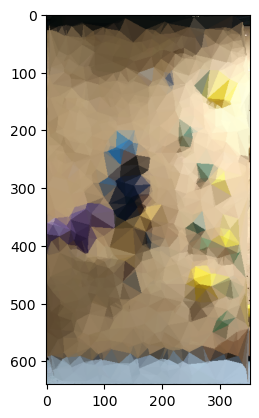

In [93]:
plt.imshow(img[:,:,[2,1,0]])
plt.show()

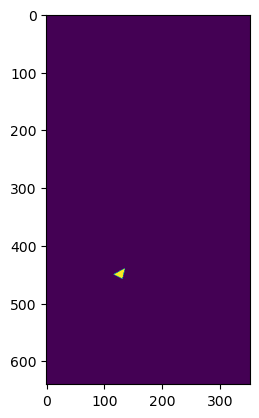

In [91]:
plt.imshow(mask)
plt.show()